<a href="https://colab.research.google.com/github/BenjaAR/LAB_07_AQUINO_MD/blob/main/LAB07_AQUINO_REYES.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [54]:
# Instalar librerías necesarias (si no están instaladas)
!pip install pandas numpy scikit-learn statsmodels matplotlib seaborn


In [55]:
# Importar las librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix

In [56]:
# Función para cargar los datos desde una URL
def get_data_from(url):
    """
    Retrieve data from a CSV into a dataframe
    input:
        url: string
    output:
        dataframe
    """
    return pd.read_csv(url, header=None)

# Función para limpiar los datos (reemplaza '?' con NaN y elimina filas con datos faltantes)
def clean_data(df):
    # Reemplazar '?' con NaN
    df.replace('?', np.nan, inplace=True)
    # Imputar valores faltantes en 'Bare_nuclei' con la mediana
    df['Bare_nuclei'] = df['Bare_nuclei'].astype(float)  # Convertir a float si es necesario
    df['Bare_nuclei'] = df['Bare_nuclei'].fillna(df['Bare_nuclei'].median())  # Cambiar inplace=True por asignación
    return df


In [57]:

# Cargar el dataset
URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/breast-cancer-wisconsin.data"
df = get_data_from(URL)

# Nombres de las columnas basados en la descripción del dataset
columns = [
    'ID', 'Clump_thickness', 'Uniformity_of_cell_size', 'Uniformity_of_cell_shape',
    'Marginal_adhesion', 'Single_epithelial_cell_size', 'Bare_nuclei',
    'Bland_chromatin', 'Normal_nucleoli', 'Mitoses', 'Class'
]
df.columns = columns

# Limpiar los datos
df = clean_data(df)

# Convertir la columna 'Class' a valores numéricos: 2 -> 0 (benigno), 4 -> 1 (maligno)
df['Class'] = df['Class'].map({2: 0, 4: 1})

# Separar las variables numéricas y la variable objetivo
target = 'Class'
X = df.drop(columns=[target, 'ID'])  # Excluimos la columna ID
y = df[target]


In [58]:

# Calcular el Information Value (IV)
def calculate_iv(df, target):
    iv_df = pd.DataFrame(columns=["Variable", "IV"])

    for col in df.drop(columns=[target]).columns:
        if df[col].dtype == 'object' or len(df[col].unique()) < 10:  # Variable categórica
            # Calculamos IV para variable categórica
            crosstab = pd.crosstab(df[col], df[target])
            total = crosstab.sum(axis=1)
            good = crosstab[1]  # Suponiendo que '1' es la clase positiva (maligno)
            bad = total - good

            dist_good = good / good.sum()
            dist_bad = bad / bad.sum()
            iv = ((dist_good - dist_bad) * np.log(dist_good / dist_bad)).sum()
        else:  # Variable numérica
            # Aquí calculamos IV para variable numérica (por ejemplo, usando bins)
            df[col+'_bin'] = pd.cut(df[col], bins=5, labels=False)
            crosstab = pd.crosstab(df[col+'_bin'], df[target])
            total = crosstab.sum(axis=1)
            good = crosstab[1]  # Suponiendo que '1' es la clase positiva (maligno)
            bad = total - good

            dist_good = good / good.sum()
            dist_bad = bad / bad.sum()
            iv = ((dist_good - dist_bad) * np.log(dist_good / dist_bad)).sum()

        # Usamos pd.concat para agregar la fila en lugar de append
        iv_df = pd.concat([iv_df, pd.DataFrame({"Variable": [col], "IV": [iv]})], ignore_index=True)

    return iv_df

# Calcular el IV
iv_df = calculate_iv(df, target)

# Filtrar las variables con IV alto (por ejemplo, IV > 0.02) y excluir variables con IV infinito
iv_df = iv_df[(iv_df['IV'] > 0.02) & (iv_df['IV'] != np.inf)]

# Mostrar el IV
print("Variables con alto poder predictivo (IV > 0.02):")
print(iv_df)

Variables con alto poder predictivo (IV > 0.02):
                      Variable        IV
2      Uniformity_of_cell_size  5.716812
5  Single_epithelial_cell_size  3.786920
6                  Bare_nuclei  4.741857
8              Normal_nucleoli  3.703119


/usr/local/lib/python3.11/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
<ipython-input-58-9c3d9049e3c2>:29: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  iv_df = pd.concat([iv_df, pd.DataFrame({"Variable": [col], "IV": [iv]})], ignore_index=True)


In [59]:

# Preprocesar los datos: dividir en entrenamiento y prueba (75% entrenamiento, 25% prueba)
# Ahora solo usamos las columnas que tienen un IV alto
X_filtered = X[iv_df['Variable']]

X_train, X_test, y_train, y_test = train_test_split(X_filtered, y, test_size=0.25, random_state=42)

# Escalado de características numéricas
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [60]:
# Modelo de Regresión Logística
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

# Evaluar el modelo
y_pred_log_reg = log_reg.predict(X_test_scaled)

# Resultados
print("Modelo de Regresión Logística:")
print(classification_report(y_test, y_pred_log_reg))


Modelo de Regresión Logística:
              precision    recall  f1-score   support

           0       0.93      0.97      0.95       118
           1       0.92      0.86      0.89        57

    accuracy                           0.93       175
   macro avg       0.93      0.91      0.92       175
weighted avg       0.93      0.93      0.93       175



In [61]:
# Modelo de SVM
svm_model = SVC()
svm_model.fit(X_train_scaled, y_train)

# Evaluar el modelo
y_pred_svm = svm_model.predict(X_test_scaled)

# Resultados
print("Modelo SVM:")
print(classification_report(y_test, y_pred_svm))


Modelo SVM:
              precision    recall  f1-score   support

           0       0.98      0.96      0.97       118
           1       0.92      0.96      0.94        57

    accuracy                           0.96       175
   macro avg       0.95      0.96      0.96       175
weighted avg       0.96      0.96      0.96       175



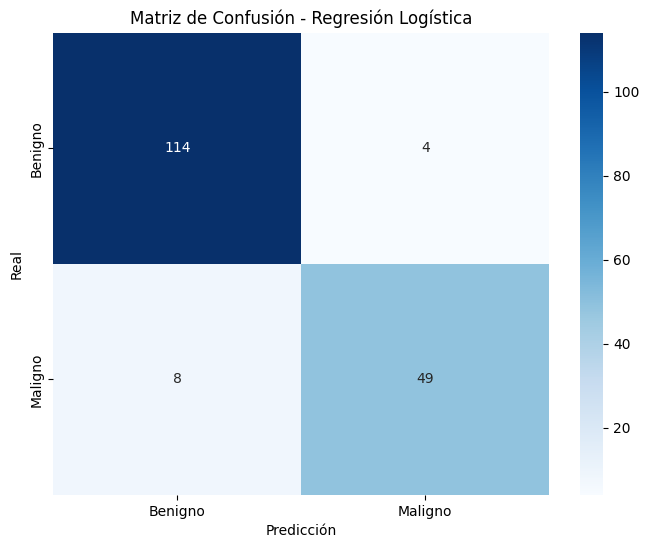

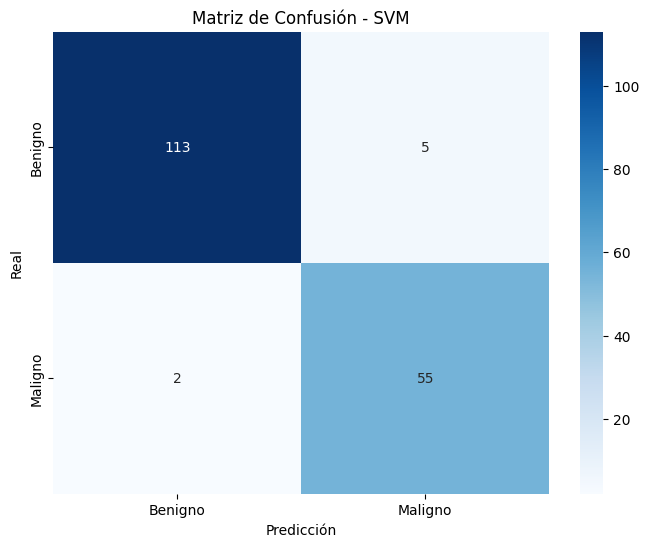

In [62]:
# Comparación de las métricas: matriz de confusión
def plot_confusion_matrix(cm, model_name):
    """
    Dibuja un mapa de calor para la matriz de confusión.
    input: cm (array) - matriz de confusión
           model_name (str) - nombre del modelo para la etiqueta
    """
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', xticklabels=['Benigno', 'Maligno'], yticklabels=['Benigno', 'Maligno'])
    plt.title(f'Matriz de Confusión - {model_name}')
    plt.xlabel('Predicción')
    plt.ylabel('Real')
    plt.show()

# Matrices de confusión
cm_log_reg = confusion_matrix(y_test, y_pred_log_reg)
cm_svm = confusion_matrix(y_test, y_pred_svm)

# Dibujar las matrices de confusión
plot_confusion_matrix(cm_log_reg, 'Regresión Logística')
plot_confusion_matrix(cm_svm, 'SVM')